In [1]:
import pandas as pd

df = pd.read_csv("diabetes_pipeline/dataset/kaggle_diabetes.csv")

df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,2,138,62,35,0,33.6,0.127,47,1
1,0,84,82,31,125,38.2,0.233,23,0
2,0,145,0,0,0,44.2,0.630,31,1
3,0,135,68,42,250,42.3,0.365,24,1
4,1,139,62,41,480,40.7,0.536,21,0


In [2]:
df.shape

(2000, 9)

In [3]:
df.columns

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='str')

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               2000 non-null   int64  
 1   Glucose                   2000 non-null   int64  
 2   BloodPressure             2000 non-null   int64  
 3   SkinThickness             2000 non-null   int64  
 4   Insulin                   2000 non-null   int64  
 5   BMI                       2000 non-null   float64
 6   DiabetesPedigreeFunction  2000 non-null   float64
 7   Age                       2000 non-null   int64  
 8   Outcome                   2000 non-null   int64  
dtypes: float64(2), int64(7)
memory usage: 140.8 KB


In [5]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,3.703500,121.182500,69.145500,20.935000,80.254000,32.193000,0.470930,33.090500,0.342000
std,3.306063,32.068636,19.188315,16.103243,111.180534,8.149901,0.323553,11.786423,0.474498
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,63.500000,0.000000,0.000000,27.375000,0.244000,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,40.000000,32.300000,0.376000,29.000000,0.000000
75%,6.000000,141.000000,80.000000,32.000000,130.000000,36.800000,0.624000,40.000000,1.000000
max,17.000000,199.000000,122.000000,110.000000,744.000000,80.600000,2.420000,81.000000,1.000000


In [6]:
df['Outcome'].value_counts()

Outcome
0    1316
1     684
Name: count, dtype: int64

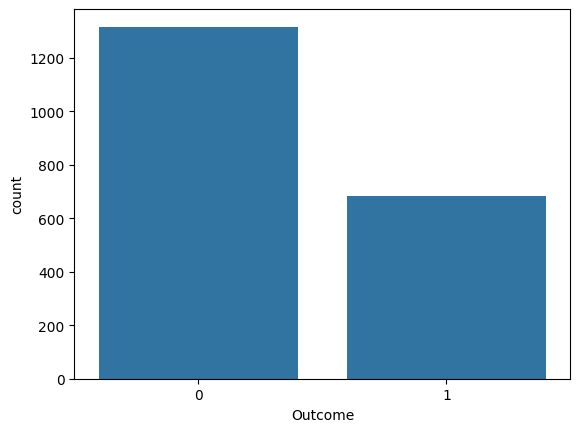

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='Outcome', data=df)
plt.show()

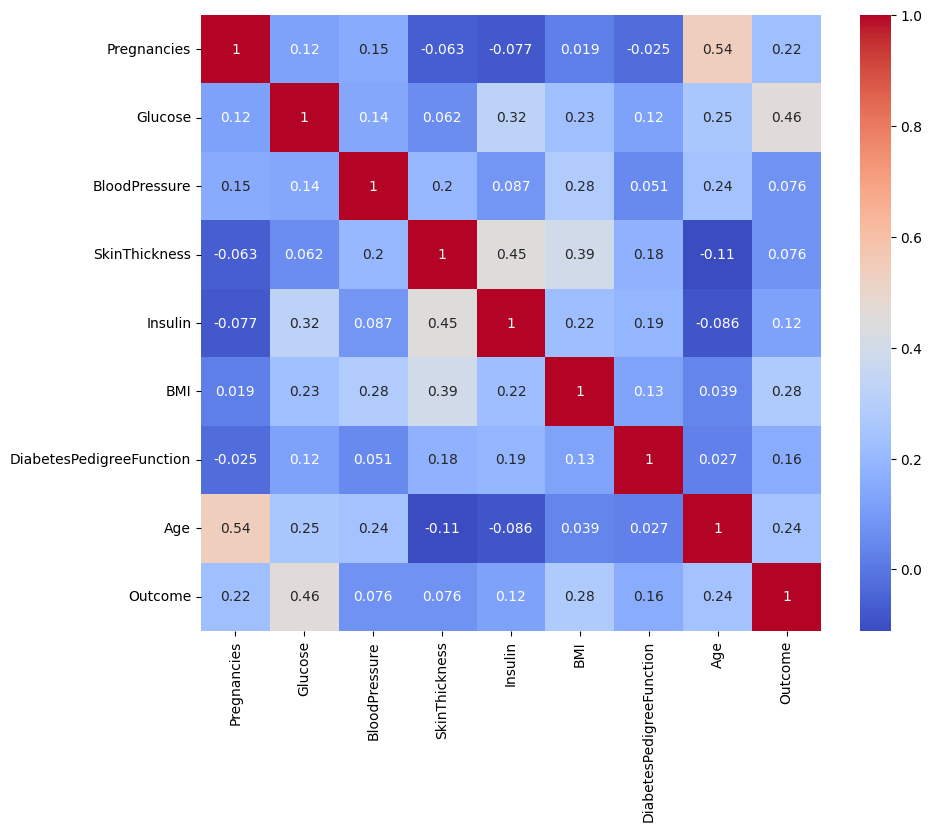

In [8]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.show()

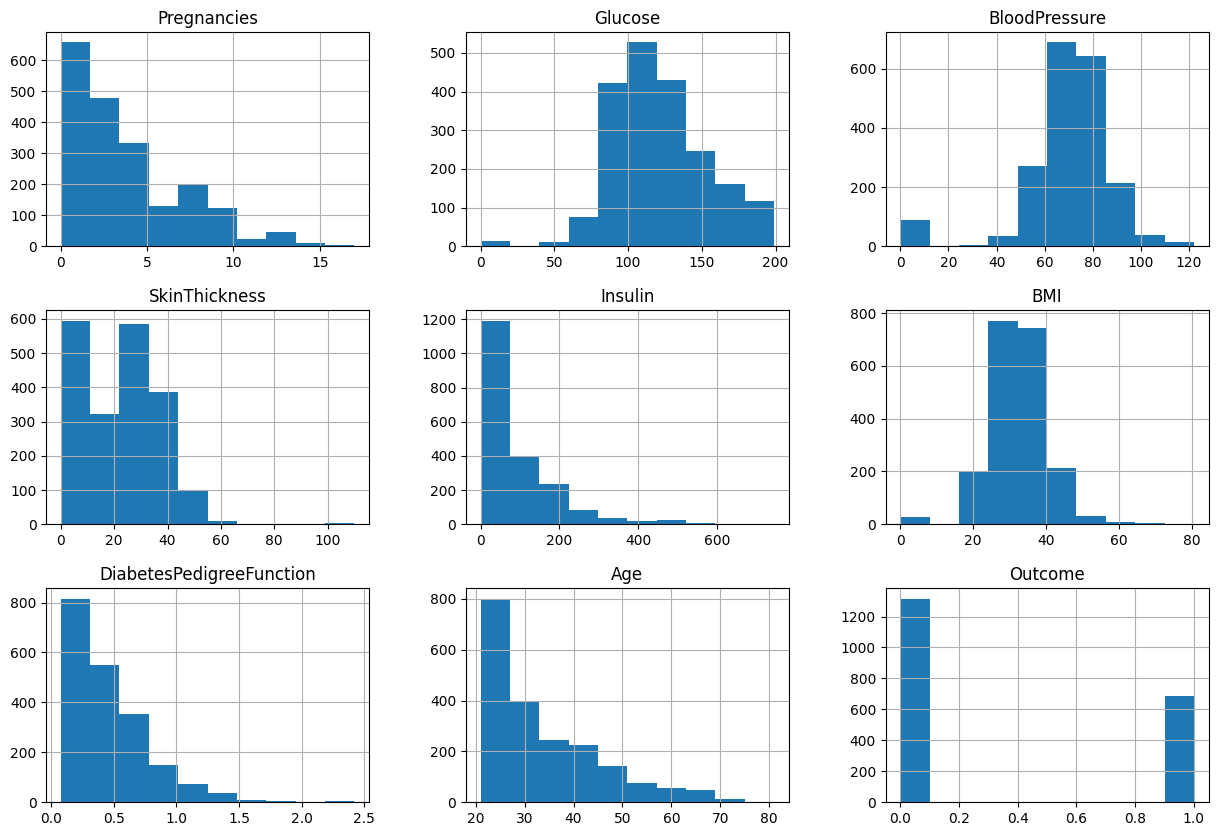

In [9]:
df.hist(figsize=(15,10))
plt.show()

In [10]:
print("Glucose:", (df['Glucose'] == 0).sum())
print("BloodPressure:", (df['BloodPressure'] == 0).sum())
print("SkinThickness:", (df['SkinThickness'] == 0).sum())
print("Insulin:", (df['Insulin'] == 0).sum())
print("BMI:", (df['BMI'] == 0).sum())

Glucose: 13
BloodPressure: 90
SkinThickness: 573
Insulin: 956
BMI: 28


In [11]:
df['Outcome'].value_counts(normalize=True) * 100

Outcome
0    65.8
1    34.2
Name: proportion, dtype: float64

In [12]:
df_clean = df.copy()

In [13]:
df_clean['Glucose'] = df_clean['Glucose'].replace(0, df_clean['Glucose'].median())

df_clean['BloodPressure'] = df_clean['BloodPressure'].replace(
    0,
    df_clean['BloodPressure'].median()
)

df_clean['SkinThickness'] = df_clean['SkinThickness'].replace(
    0,
    df_clean['SkinThickness'].median()
)

df_clean['Insulin'] = df_clean['Insulin'].replace(
    0,
    df_clean['Insulin'].median()
)

df_clean['BMI'] = df_clean['BMI'].replace(
    0,
    df_clean['BMI'].median()
)

In [14]:
print("Glucose:", (df_clean['Glucose'] == 0).sum())
print("BloodPressure:", (df_clean['BloodPressure'] == 0).sum())
print("SkinThickness:", (df_clean['SkinThickness'] == 0).sum())
print("Insulin:", (df_clean['Insulin'] == 0).sum())
print("BMI:", (df_clean['BMI'] == 0).sum())

Glucose: 0
BloodPressure: 0
SkinThickness: 0
Insulin: 0
BMI: 0


In [15]:
X = df_clean.drop('Outcome', axis=1)
y = df_clean['Outcome']

In [16]:
X.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
0,2,138,62,35,40,33.6,0.127,47
1,0,84,82,31,125,38.2,0.233,23
2,0,145,72,23,40,44.2,0.630,31
3,0,135,68,42,250,42.3,0.365,24
4,1,139,62,41,480,40.7,0.536,21


In [17]:
y.head()

0    1
1    0
2    1
3    1
4    0
Name: Outcome, dtype: int64

In [18]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [19]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(1600, 8)
(400, 8)
(1600,)
(400,)


In [20]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [21]:
X_train[:5]

array([[ 0.98074278,  2.40507746, -0.20041587,  0.60395292,  0.47267074,
        -1.05242234, -0.94027493,  1.89407388],
       [-0.81466734, -1.00483938, -0.7055333 , -0.38455834, -0.60351726,
        -0.47815096, -0.8508536 , -1.02757012],
       [ 0.38227274, -0.15236017,  0.64144653,  0.49411834, -0.60351726,
         1.17463009, -0.3759955 ,  0.34732117],
       [-0.51543232, -0.02120952, -0.20041587,  0.49411834, -0.03979974,
         0.90850433,  1.28909136, -0.85570871],
       [-0.81466734, -0.08678484,  1.31493644,  1.48262959,  0.72890597,
         1.77691471,  0.12044706, -0.59791659]])

In [22]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression()

lr.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default sol

In [23]:
y_pred = lr.predict(X_test)

In [24]:
from sklearn.metrics import accuracy_score

accuracy_score(y_test, y_pred)

0.775

In [25]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.77      0.91      0.84       253
           1       0.78      0.54      0.64       147

    accuracy                           0.78       400
   macro avg       0.78      0.73      0.74       400
weighted avg       0.78      0.78      0.76       400



In [27]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(random_state=42)

dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

In [28]:
from sklearn.metrics import accuracy_score

accuracy_score(y_test, y_pred_dt)

0.9725

In [29]:
print(classification_report(y_test, y_pred_dt))

              precision    recall  f1-score   support

           0       0.99      0.96      0.98       253
           1       0.94      0.99      0.96       147

    accuracy                           0.97       400
   macro avg       0.97      0.98      0.97       400
weighted avg       0.97      0.97      0.97       400



In [30]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

In [31]:
accuracy_score(y_test, y_pred_rf)

0.99

In [32]:
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.99      0.99      0.99       253
           1       0.99      0.99      0.99       147

    accuracy                           0.99       400
   macro avg       0.99      0.99      0.99       400
weighted avg       0.99      0.99      0.99       400



In [33]:
import pandas as pd

results = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'Decision Tree',
        'Random Forest'
    ],
    'Accuracy': [
        accuracy_score(y_test, y_pred),
        accuracy_score(y_test, y_pred_dt),
        accuracy_score(y_test, y_pred_rf)
    ]
})

results

,Model,Accuracy
0,Logistic Regression,0.7750
1,Decision Tree,0.9725
2,Random Forest,0.9900


In [34]:
df.duplicated().sum()

np.int64(1256)

In [35]:
df_clean.corr()['Outcome'].sort_values(ascending=False)

Outcome                     1.000000
Glucose                     0.487712
BMI                         0.282515
Age                         0.236509
Pregnancies                 0.224437
SkinThickness               0.181365
BloodPressure               0.174184
DiabetesPedigreeFunction    0.155459
Insulin                     0.145165
Name: Outcome, dtype: float64

In [36]:
import pickle

pickle.dump(rf, open('diabetes_model.pkl', 'wb'))

In [37]:
pickle.dump(scaler, open('scaler.pkl', 'wb'))

In [38]:
import os

os.listdir()

['Diabetes_Classification.ipynb',
 'diabetes_model.pkl',
 'diabetes_pipeline',
 'Diabetes_prediction_deployed',
 'README.md',
 'scaler.pkl',
 'venv']